In [1]:
import matplotlib
import pandas as pd
import numpy as np
import boost_histogram as bh
import dask.dataframe as dd
import tqdm
import h5py

import matplotlib.pyplot as plt

# Estimation of the Radiogenic Nuclear Recoil Background

## Neutron simulations with Geant4 (and post-processing)
We directly simulate only the neutron interactions within the TPC volume using Geant4. All other interactions (e.g. gamma, beta) don't lead to nuclear recoils and are thus not simulated. The neutron spectra inside the Geant4 simulation are taken from SOURCES-4A simulations of the detector materials.

In [2]:
fuse_file = './20251205/combined_fuse_output.h5'
parquet_file = './20251205/combined_parquet_output.h5'

fuse_keys = h5py.File(fuse_file, 'r').keys()
parquet_keys = h5py.File(parquet_file, 'r').keys()

# print available columns from hdf files
print("Fuse data columns: ", fuse_keys)
print("Parquet data columns: ", parquet_keys)

assert fuse_keys == parquet_keys, "Columns in fuse and parquet data do not match!"

keys = list(fuse_keys)

Fuse data columns:  <KeysViewHDF5 ['run_Copper_Th232', 'run_Copper_U238', 'run_Cryostat_Th232', 'run_Cryostat_U238', 'run_PMT_Th232', 'run_PMT_U238', 'run_Sapphire_Th232', 'run_Sapphire_U238', 'run_Teflon_Th232', 'run_Teflon_U238']>
Parquet data columns:  <KeysViewHDF5 ['run_Copper_Th232', 'run_Copper_U238', 'run_Cryostat_Th232', 'run_Cryostat_U238', 'run_PMT_Th232', 'run_PMT_U238', 'run_Sapphire_Th232', 'run_Sapphire_U238', 'run_Teflon_Th232', 'run_Teflon_U238']>


In [3]:
key = keys[0]

def load_data(key, dask=False):
    columns=['runid', 'x', 'y', 'z', 'ed', 'cluster_id',
            'eventid', 'x_pri', 'y_pri', 'z_pri']
    if dask:
        fuse_data = dd.read_hdf('./20251205/combined_fuse_output.h5', key=key)#, columns=columns)
        parquet_data = dd.read_hdf('./20251205/combined_parquet_output.h5', key=key)#, columns=columns)
    else:
        fuse_data = pd.read_hdf('./20251205/combined_fuse_output.h5', key=key, columns=columns)
        parquet_data = pd.read_hdf('./20251205/combined_parquet_output.h5', key=key, columns=columns)

    # for x,y,z and x_pri,y_pri,z_pri to convert from cm to mm
    fuse_data[["x", "y", "z", "x_pri", "y_pri", "z_pri"]] *= 10

    fuse_data["runid"] = fuse_data["runid"].astype(int)
    parquet_data["runid"] = parquet_data["runid"].astype(int)

    return fuse_data, parquet_data

#fuse_data, parquet_data = load_data(key)
#fuse_data.head(2)

In [11]:
fuse_data, parquet_data = load_data("run_Cryostat_U238", dask=True)
df_ss, df_ms = select_ss_ms_events(fuse_data)
df_ss.head(20)

,macro,runid,x,y,z,ed,nestid,cluster_id,eventid,trackid,t,A,Z,x_pri,y_pri,z_pri,time,endtime,n_clusters
54,run_Cryostat_U238,586,-1007.228882,867.493347,-126.035835,30.759865,6,1160,162,1,0.000000,134,54,-1061.480225,1196.694946,-4.251924,67460682264,67460682264,1
63,run_Cryostat_U238,586,-797.621338,1213.708130,-1180.558228,0.904006,6,3874,586,1,0.000000,134,54,-867.784546,1274.450562,-1216.628174,226818702409,226818702409,1
64,run_Cryostat_U238,586,727.050293,-1067.295654,1138.850952,3.157609,6,4463,667,1,0.000000,136,54,544.817078,-1617.212158,1792.148560,266547735652,266547735652,1
97,run_Cryostat_U238,586,-866.755676,1013.864624,-260.089905,0.917482,6,6164,945,1,0.000000,134,54,-1026.488525,1344.693115,-531.234863,362293153121,362293153121,1
104,run_Cryostat_U238,586,-1352.959717,593.736511,415.065857,607.660522,8,8281,1207,10,0.000000,0,0,-1697.933105,-28.560425,943.974487,498449061186,498449061186,1
264,run_Cryostat_U238,586,1019.956665,-1001.591553,-878.292908,3.953198,6,12681,1748,1,0.000000,134,54,1115.902344,-1273.409302,-1060.478760,752973644933,752973644933,1
300,run_Cryostat_U238,586,125.009552,-1487.584717,-776.562439,174.839249,8,14391,1966,158,0.000000,0,0,473.624329,-1631.895874,-883.737671,838842791086,838842791086,1
494,run_Cryostat_U238,586,-1277.523560,645.790527,701.378113,1.457057,6,30781,4275,1,0.000000,136,54,-686.054077,1549.672363,1986.557373,1786247821407,1786247821407,1
537,run_Cryostat_U238,586,-295.918365,1047.457886,-451.620789,0.000248,6,32063,4414,1,0.000000,135,55,-395.723602,1495.134399,-735.473755,1864368232850,1864368232850,1
538,run_Cryostat_U238,586,440.342682,-1430.373047,-55.527958,394.937836,8,32418,4458,16,0.002033,0,0,581.922913,-1464.996582,7.352641,1892226077614,1892226077614,1


In [10]:
fuse_data[(fuse_data['eventid']==2173)&(fuse_data["runid"]==185)].compute()

,macro,runid,x,y,z,ed,nestid,cluster_id,eventid,trackid,t,A,Z,x_pri,y_pri,z_pri,time,endtime
19699,run_Copper_Th232,185,-306.155731,1451.684082,572.395935,556.742371,8,32115,2173,489,0.002912,0,0,-56.31472,1499.181885,263.324219,1579858767192,1579858767192


  0%|          | 0/10 [00:00<?, ?it/s]

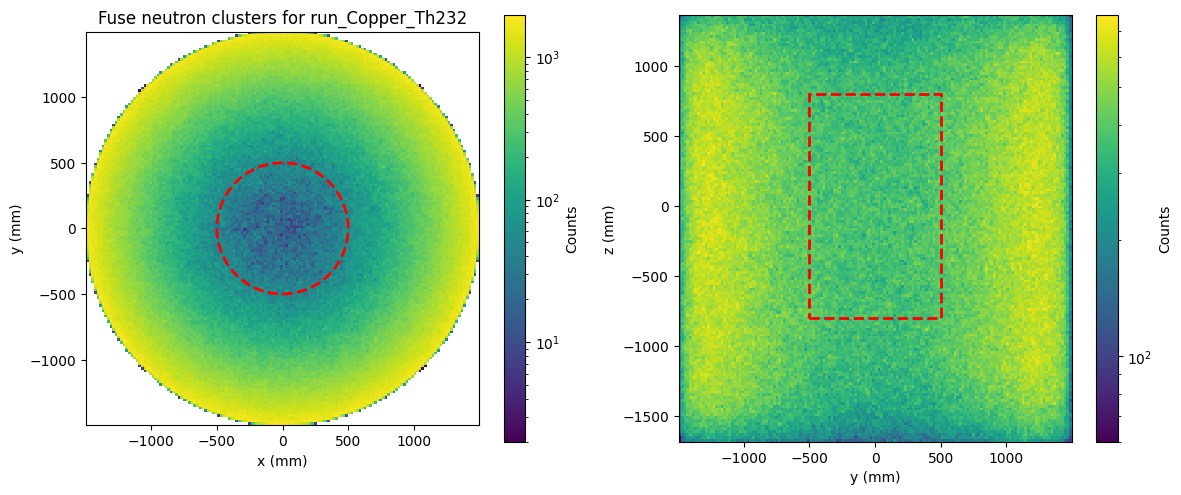

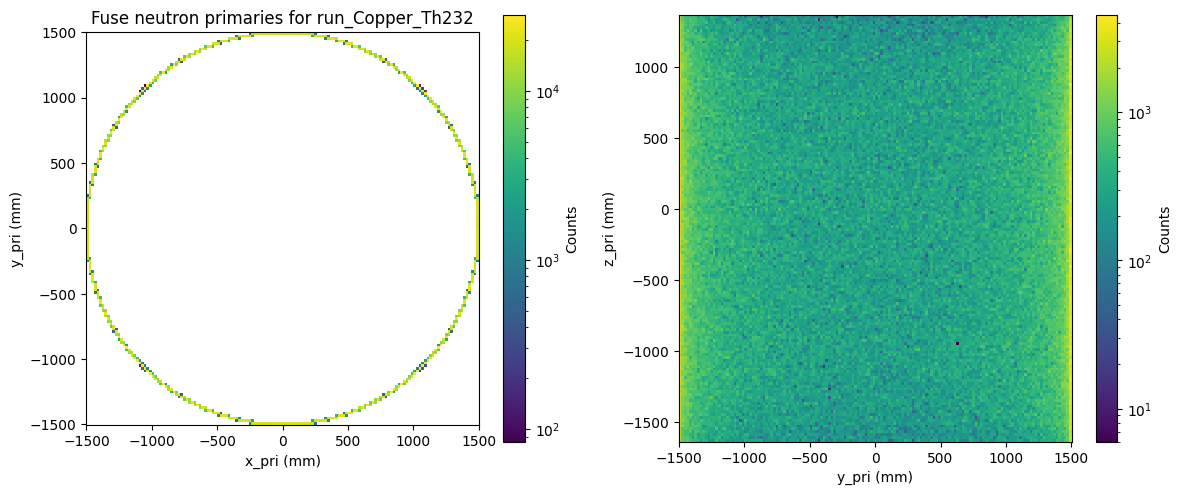

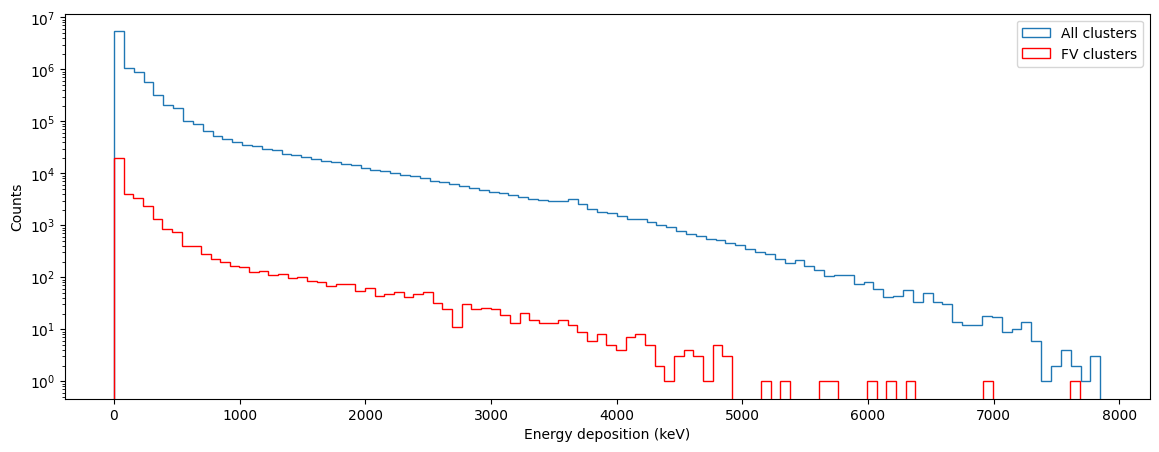

 10%|█         | 1/10 [00:26<04:01, 26.80s/it]

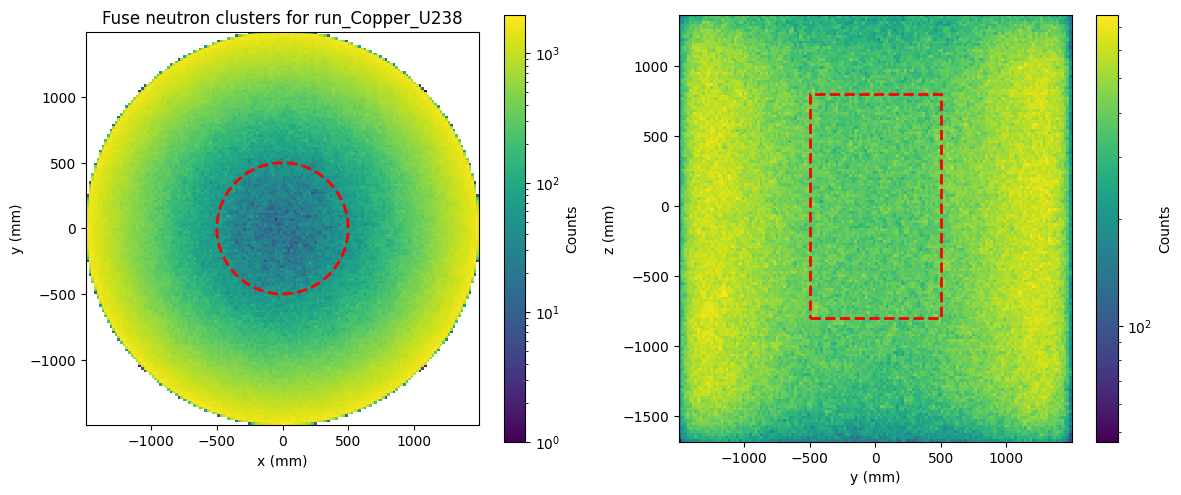

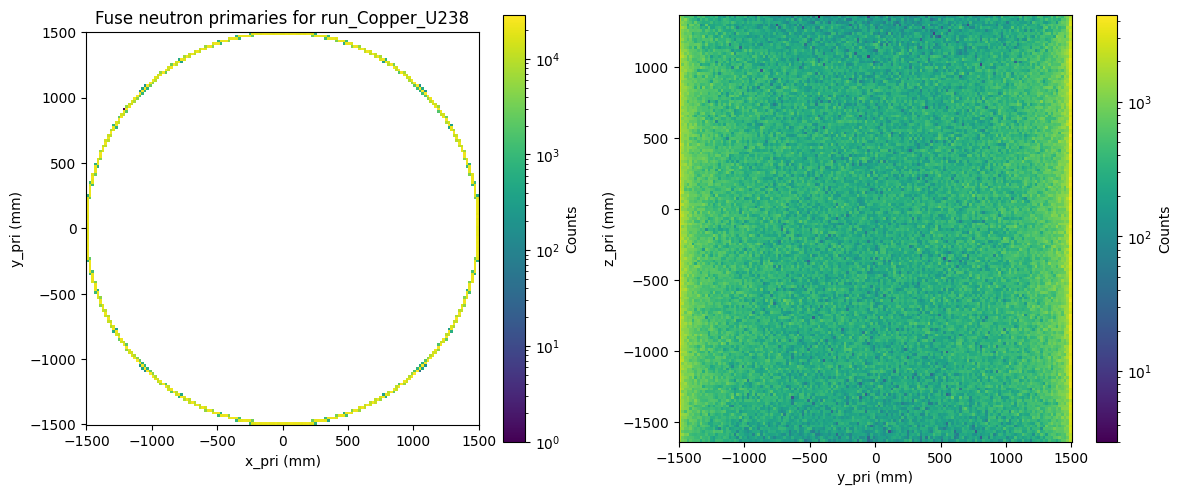

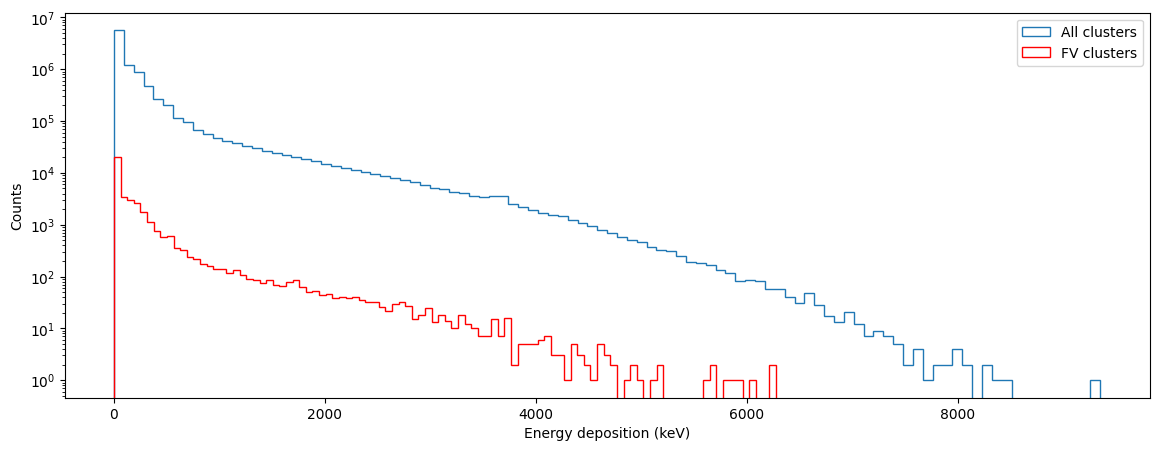

 20%|██        | 2/10 [00:52<03:28, 26.11s/it]

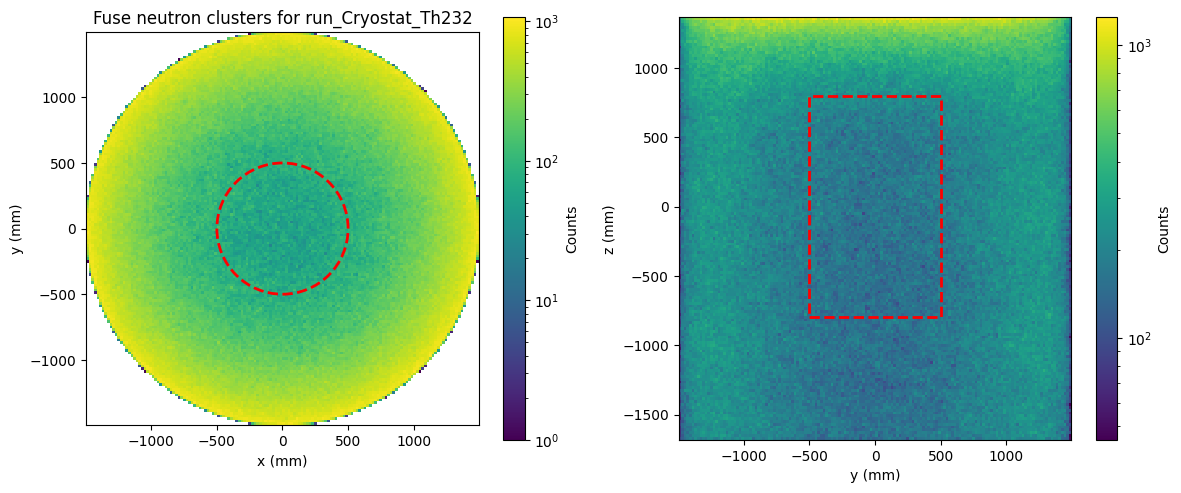

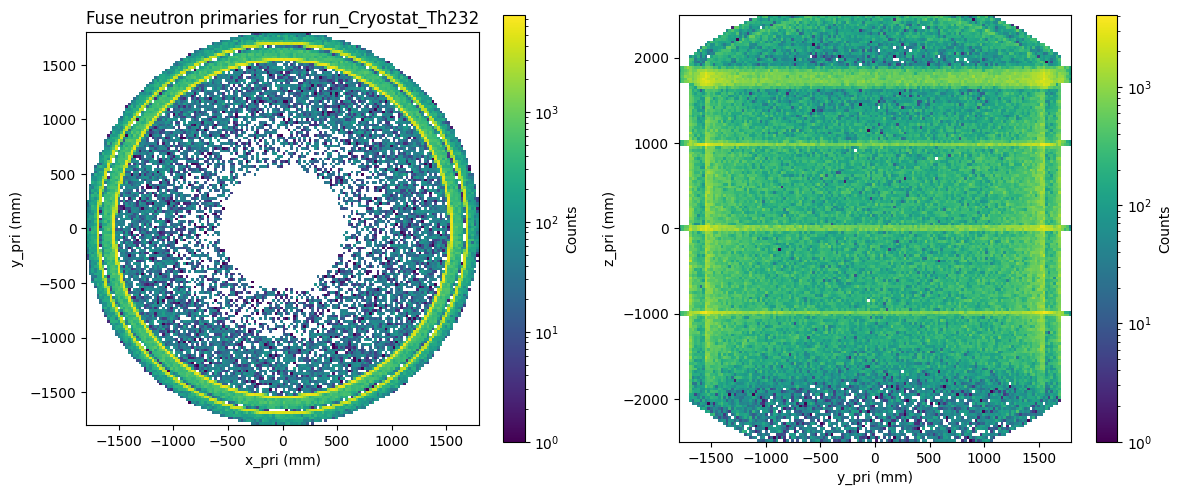

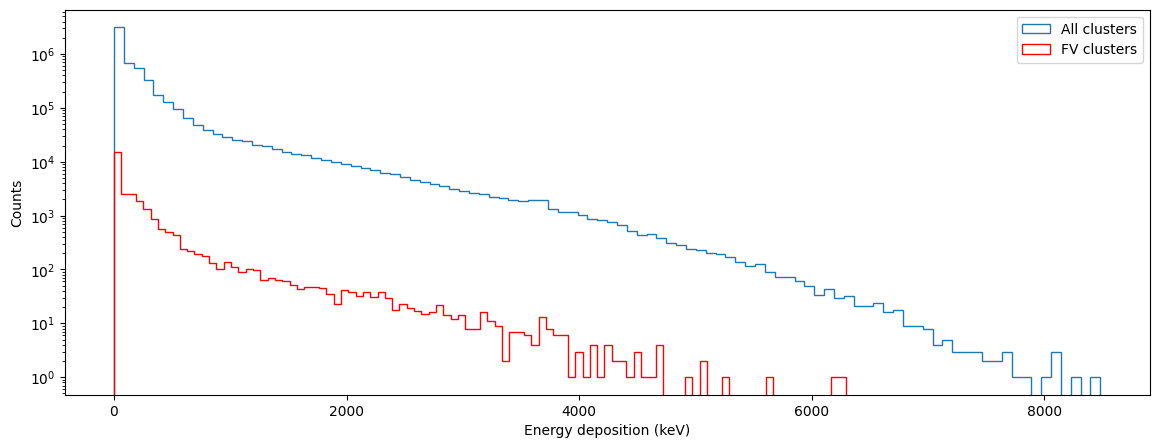

 30%|███       | 3/10 [01:11<02:41, 23.07s/it]

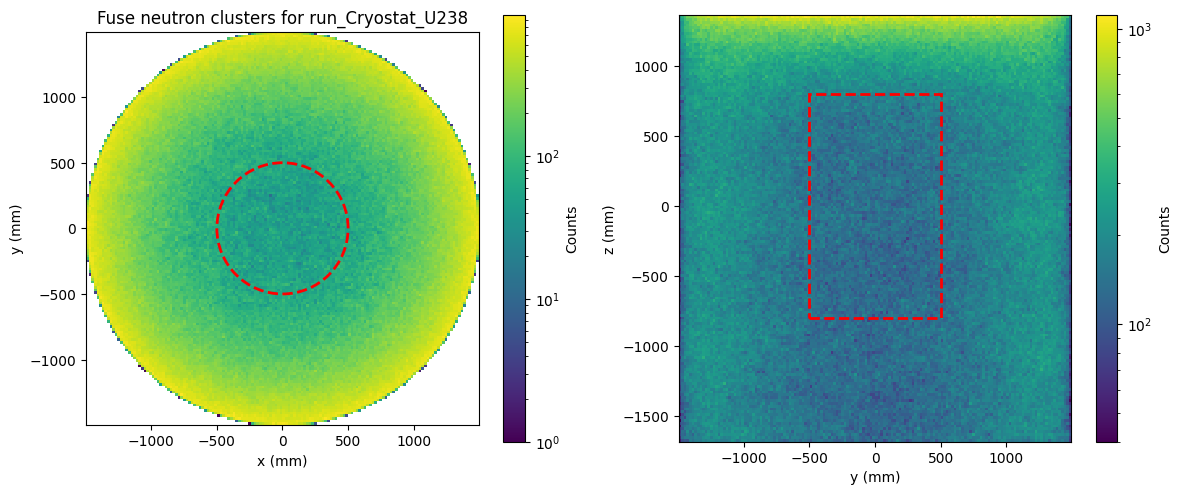

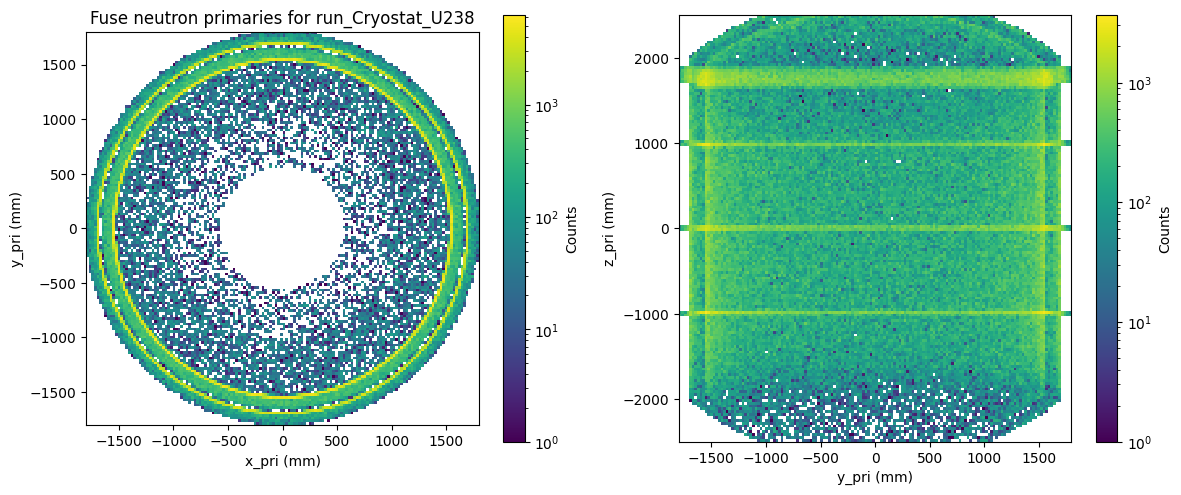

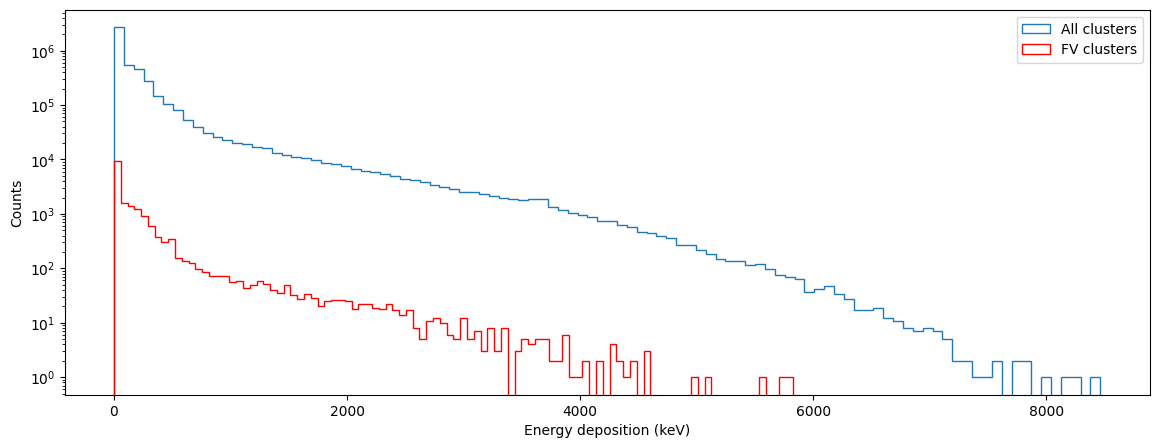

 40%|████      | 4/10 [01:28<02:01, 20.33s/it]

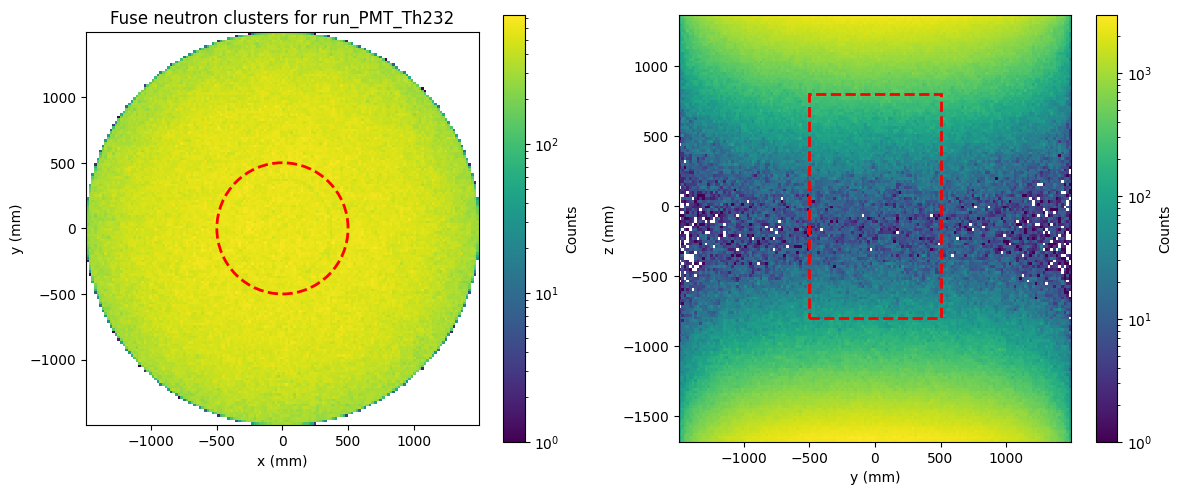

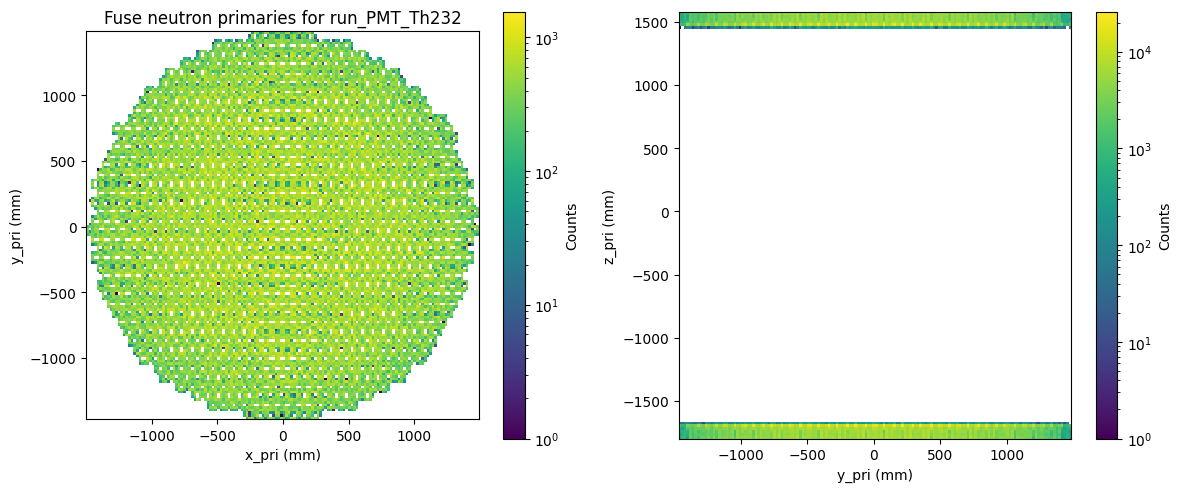

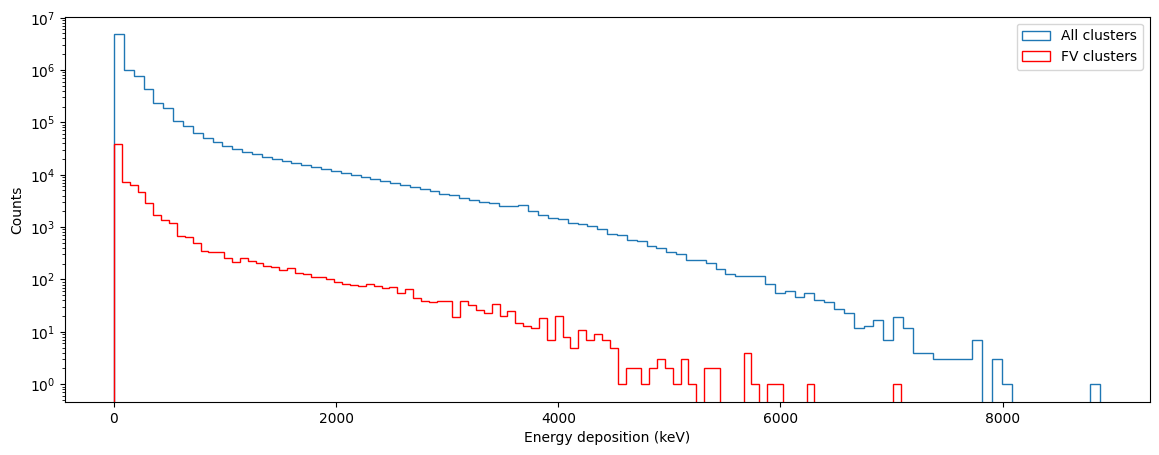

 50%|█████     | 5/10 [01:51<01:48, 21.65s/it]

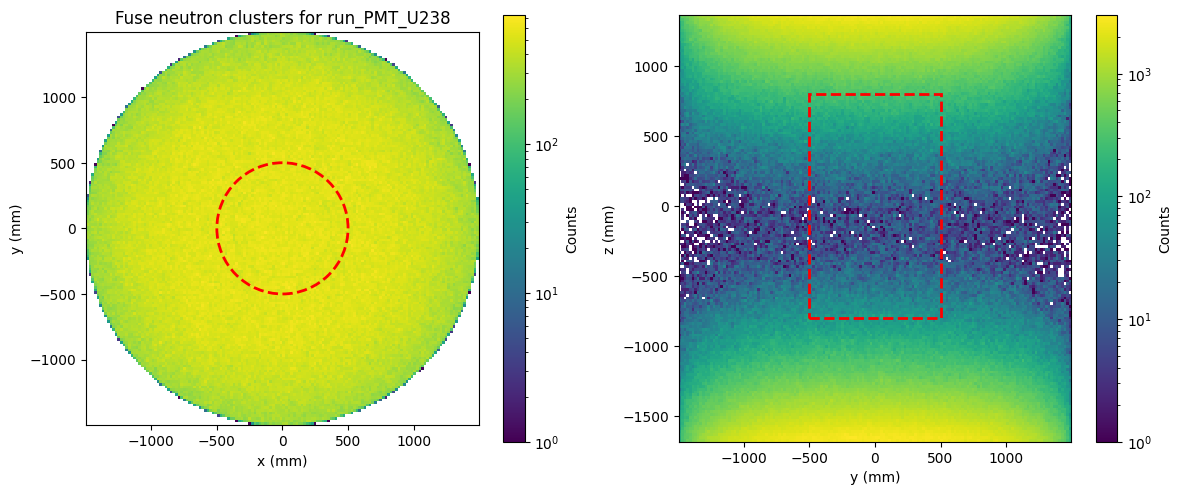

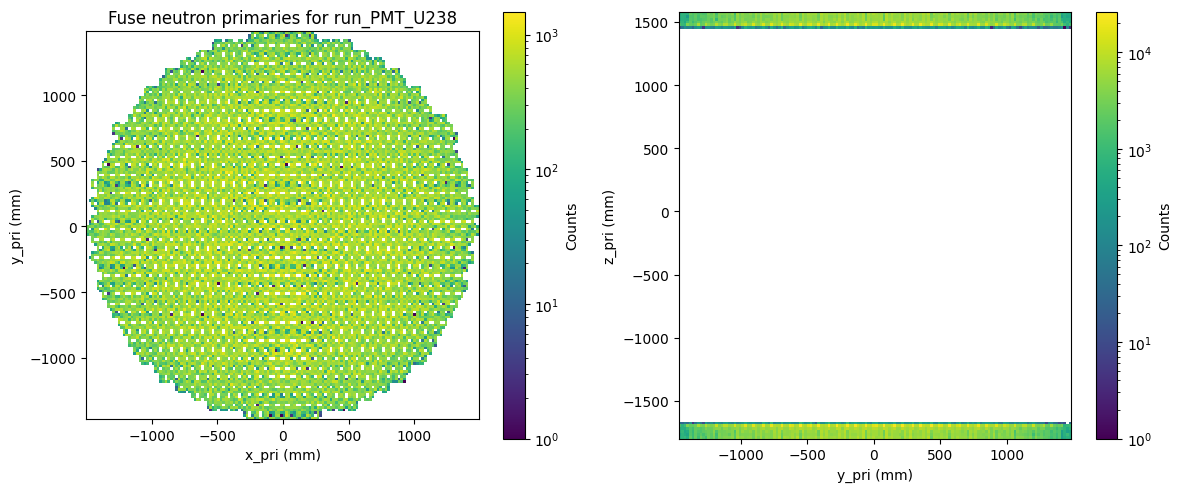

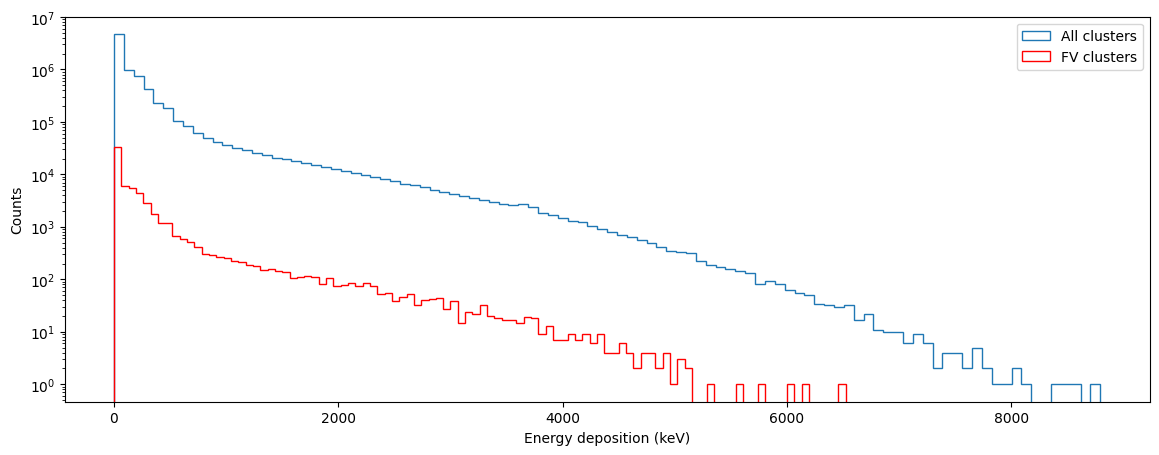

 60%|██████    | 6/10 [02:17<01:31, 22.87s/it]

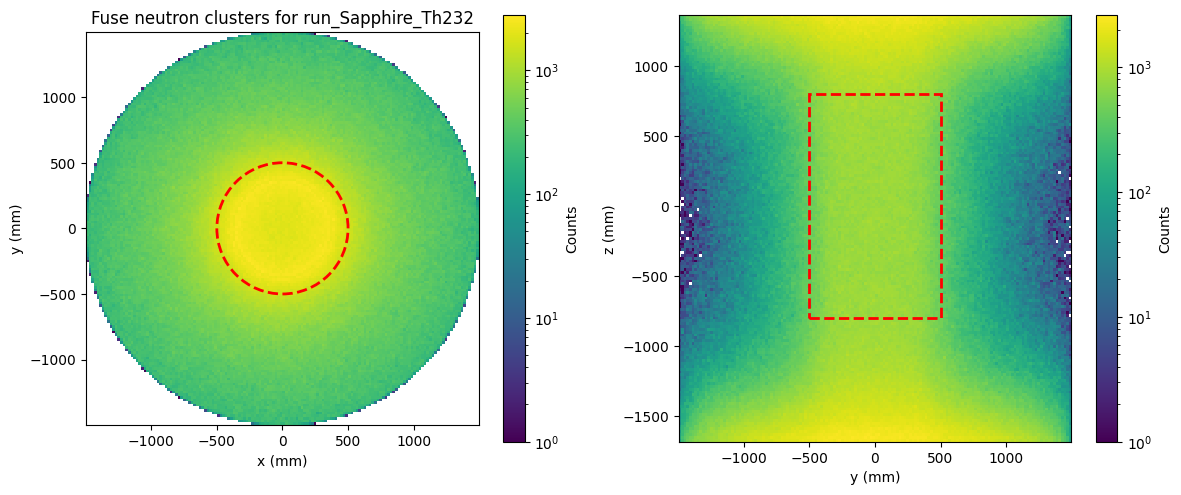

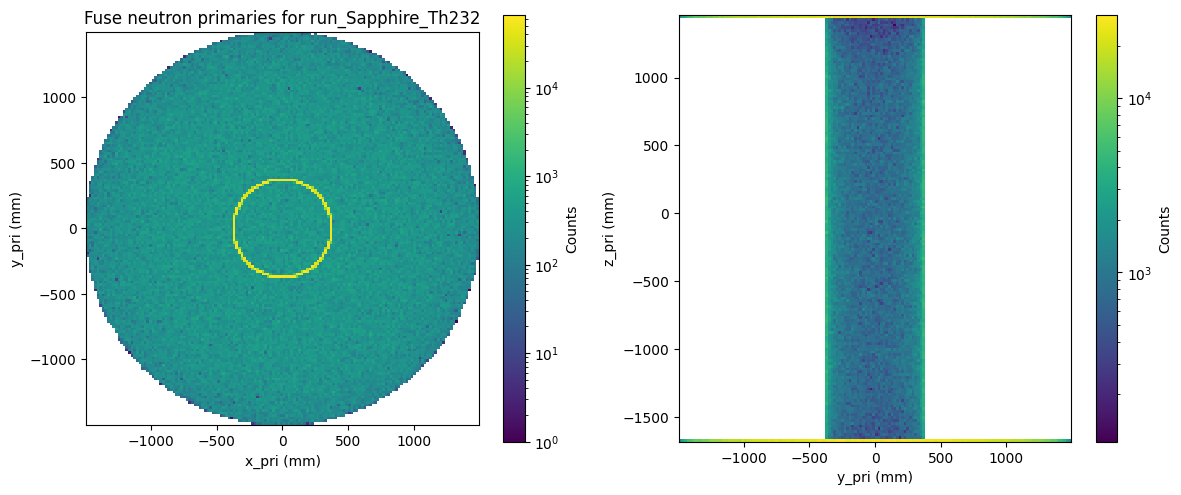

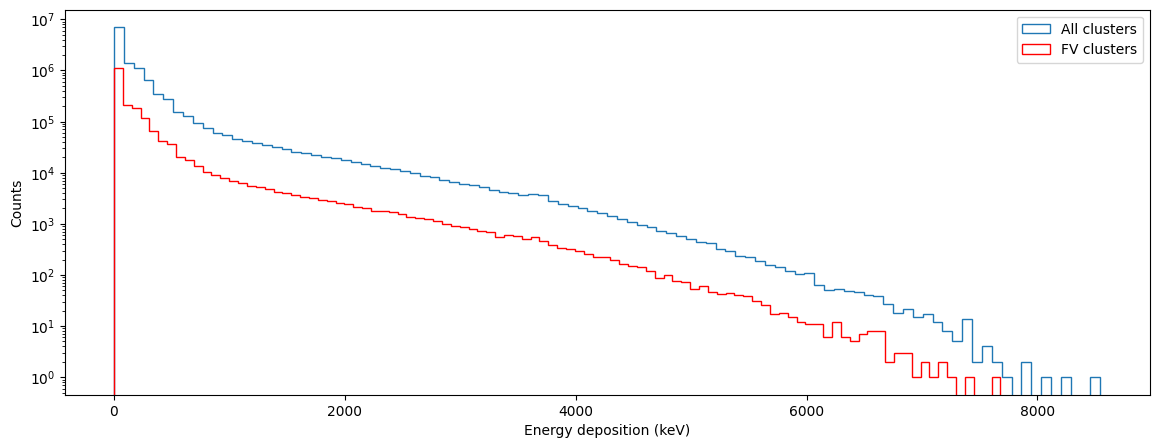

 70%|███████   | 7/10 [02:57<01:25, 28.42s/it]

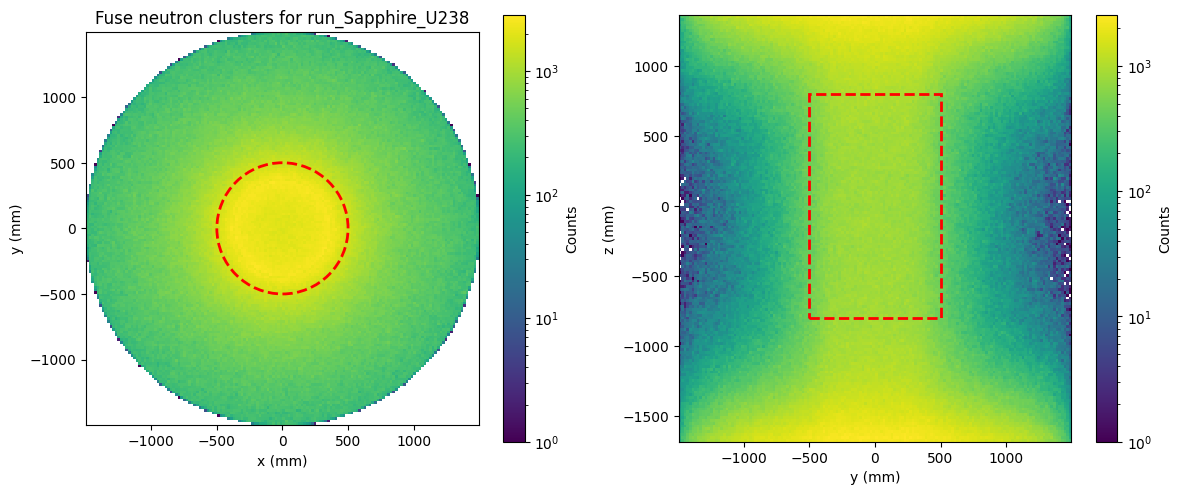

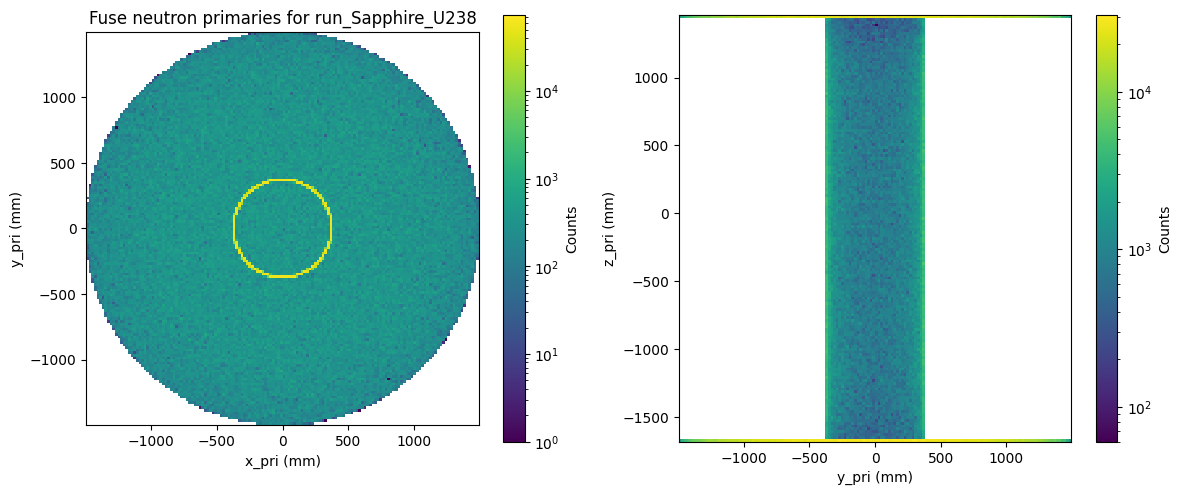

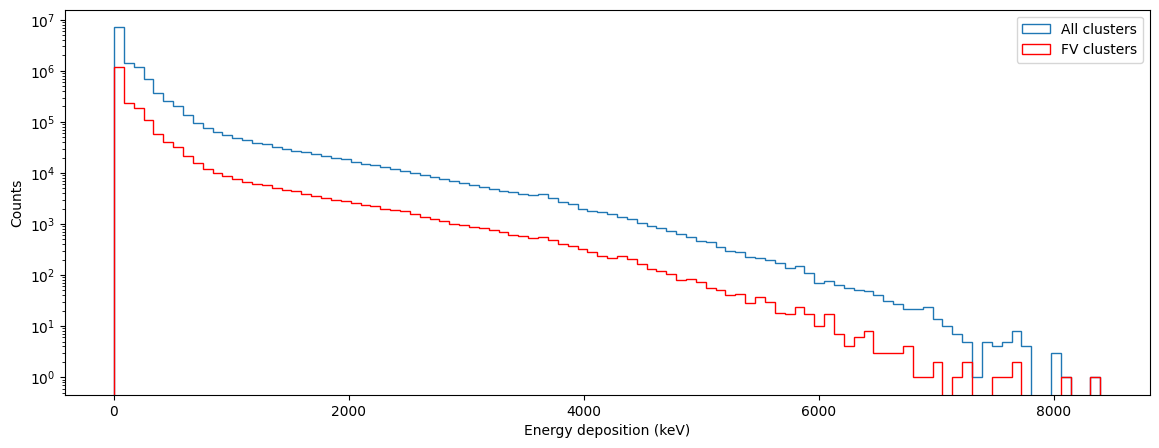

 80%|████████  | 8/10 [03:42<01:07, 33.91s/it]

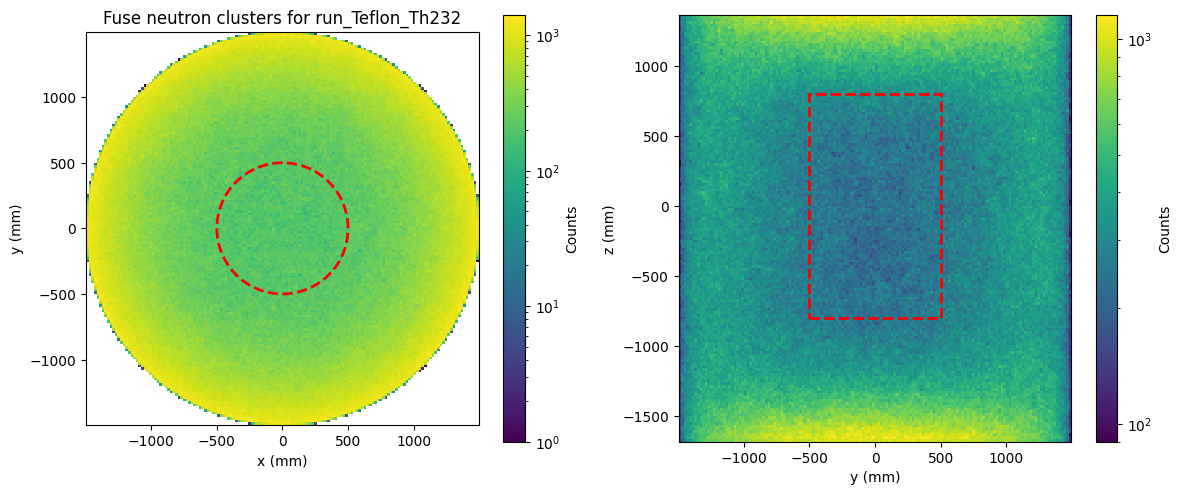

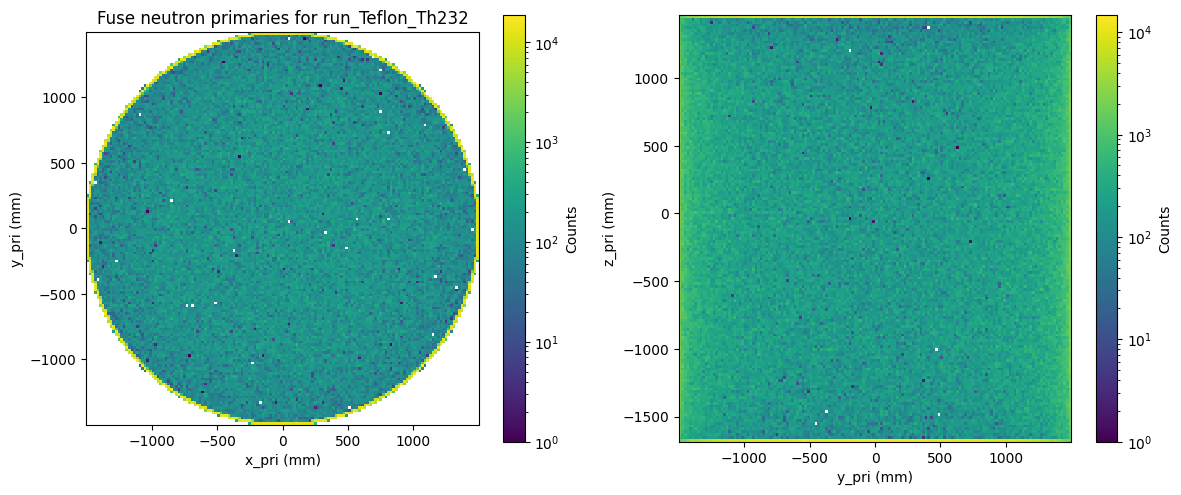

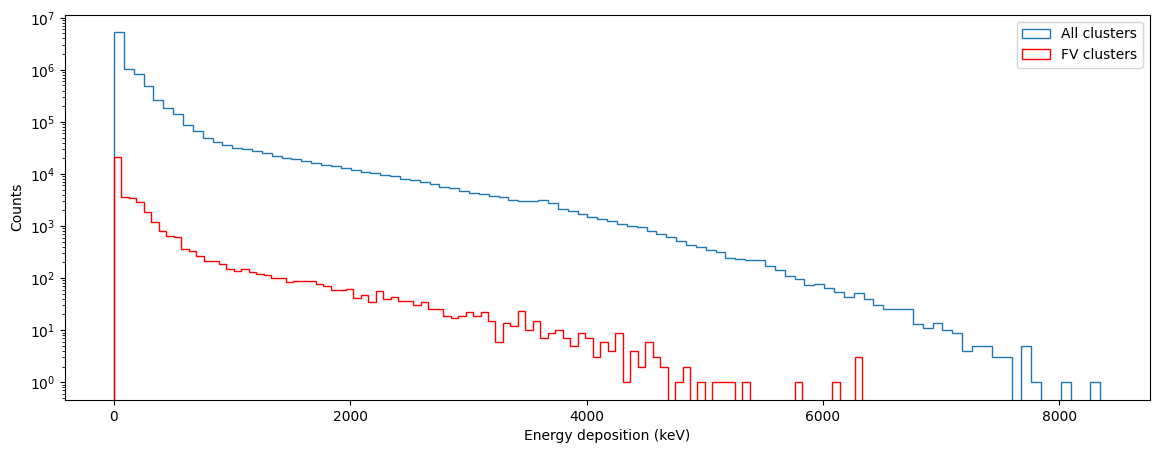

 90%|█████████ | 9/10 [04:11<00:32, 32.38s/it]

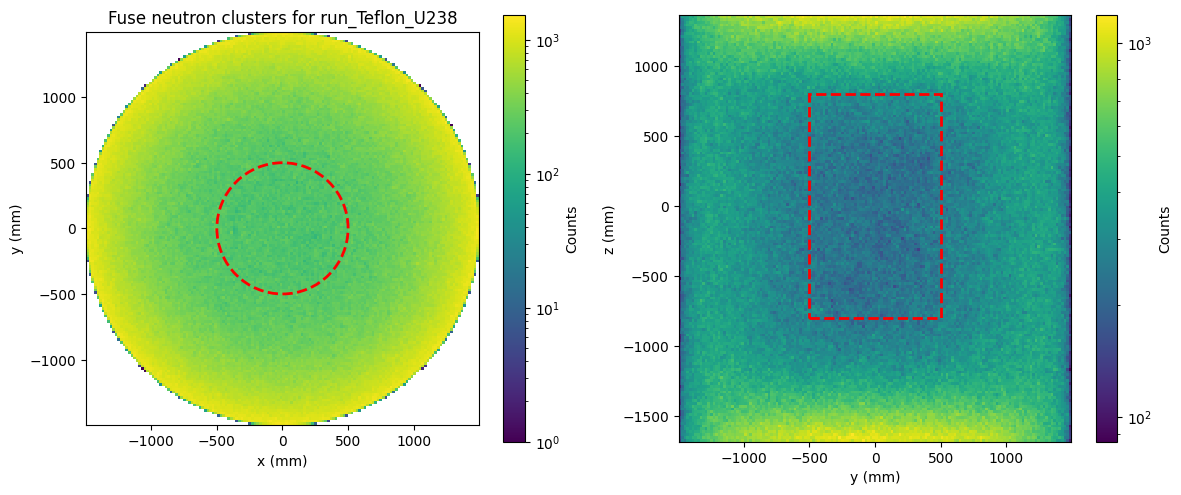

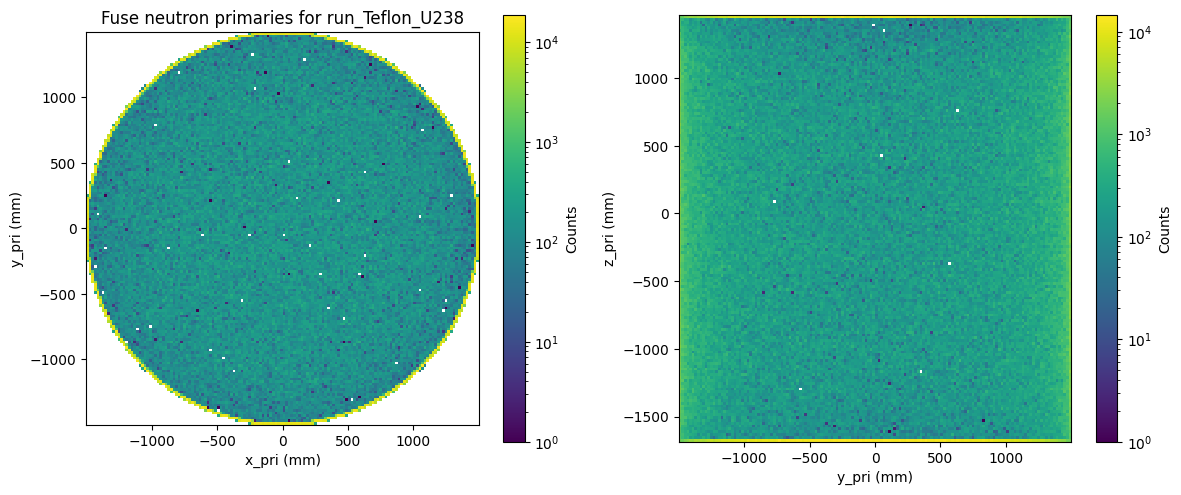

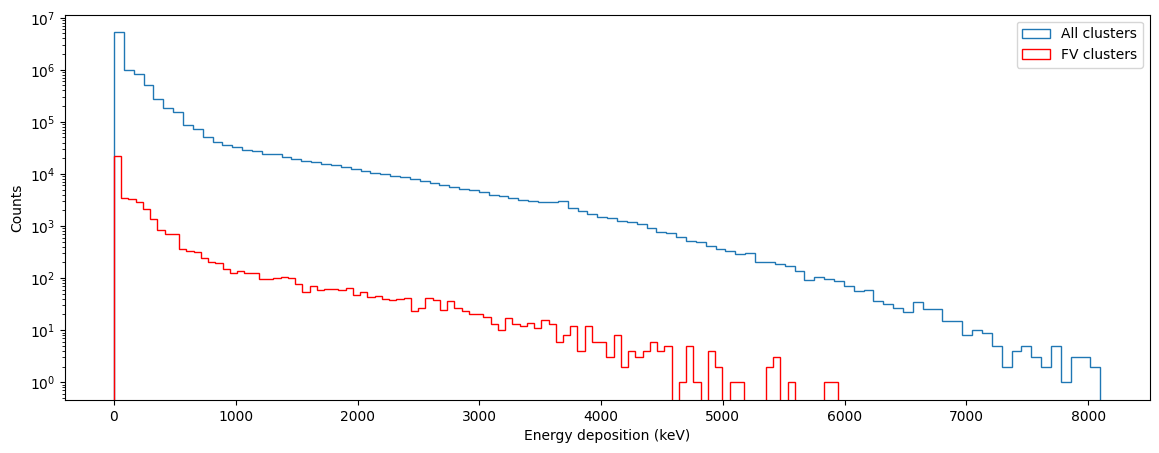

100%|██████████| 10/10 [04:37<00:00, 27.75s/it]


In [ ]:
fv_x = 500  # mm
fv_z = (-800, 800)  # mm

for key in tqdm.tqdm(keys):
    fuse_data, parquet_data = load_data(key)
    
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["x"], fuse_data["y"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Fuse neutron clusters for {key}")
    ax1.set_xlabel("x (mm)")
    ax1.set_ylabel("y (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["y"], fuse_data["z"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y (mm)")
    ax2.set_ylabel("z (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    # make a box for the fiducial volume
    ax1.add_patch(plt.Circle((0, 0), fv_x, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))
    ax2.add_patch(plt.Rectangle((-fv_x, fv_z[0]), 2*fv_x, 2*fv_z[1], color='red', fill=False, linestyle='--', linewidth=2))

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()

    plt.savefig("fuse_"+key+"_xy_yz_hist2d.png", dpi=300, bbox_inches='tight')
    plt.show()


    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["x_pri"], fuse_data["y_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Fuse neutron primaries for {key}")
    ax1.set_xlabel("x_pri (mm)")
    ax1.set_ylabel("y_pri (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["y_pri"], fuse_data["z_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y_pri (mm)")
    ax2.set_ylabel("z_pri (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()

    plt.savefig("fuse_"+key+"_xy_yz_pri_hist2d.png", dpi=300, bbox_inches='tight')
    plt.show()


    fig = plt.figure(figsize=(14,5))
    plt.hist(fuse_data["ed"], bins=100, histtype='step', label='All clusters')

    data_fv = fuse_data[fuse_data["z"].between(*fv_z) & (fuse_data["x"]**2 + fuse_data["y"]**2 <= fv_x**2)]["ed"]
    plt.hist(data_fv, bins=100, histtype='step', label='FV clusters', color='red')

    plt.legend()

    plt.xlabel("Energy deposition (keV)")
    plt.ylabel("Counts")
    plt.yscale("log")

    plt.savefig("fuse_"+key+"_ed_hist.png", dpi=300, bbox_inches='tight')
    plt.show()

## Volume and mass for each macro

In [8]:
# volume in cm3 and density in g/cm3
volumes = {
    "PMT": None, # PmtTpcTop* -> Top and Bottom PMTs
    "Cryostat": {"volume": 1.5662e+06, "density": 7.7, "confinement": "phys_oCryostat phys_iCryostat"},
    "Teflon": {"volume": 130301, "density": 2.2, "confinement": "phys_GXeTeflonTub phys_LXeTeflonTub"},
    "Copper": {"volume": 56804.8, "density": 8.92, "confinement": "phys_CopperFCTub"},
    "Sapphire": {"volume": 63877.6, "density": 3.98, "confinement": "phys_GXeSapphireTub phys_GXeSapphireCap phys_LXeSapphireTub phys_LXeSapphireCap"},
}

# calculate masses from volume and density
scalings = {}
for k, val in volumes.items():
    if val is not None:
        scalings[k] = val["volume"] * val["density"] / 1000  # convert to kg
scalings["PMT"] = 2 * 1184 # number of PMTs

LXe = {
    "density": 2.862, # g/cm3
    "temperature": 177.05, # K
    "pressure": 1.5 # bar
}

scalings

{'Cryostat': 12059.74,
 'Teflon': 286.6622,
 'Copper': 506.698816,
 'Sapphire': 254.232848,
 'PMT': 2368}

## Materials and their radiopurity

We first collect all our estimates for the materials used in the TPC and their radiopurity levels. We can use the earlier XENONnT and also DARWIN estimates. However, the DARWIN estimates are quite conservative and much higher than what we achieved in XENONnT.

In addition I found some numbers from CRESST for sapphire directly. We could also use the screening results for the ceramic stem of the XENON PMTs but these are expected to be higher since they are made out of ceramix Al2O3 instead of pure sapphire (Al2O3 single crystal).

Further information from XENONnT:
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt:ramirez:20171108_xenonnt_radiogenic_nr_bkg_simulations
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt_sr0:neutron_background_updated_template
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt:analysis:sr0_1_nr_background

In [9]:
neutron_sources = ["U235", "U238", "Th228", "Th232", "Ra226"]

# https://www.sciencedirect.com/science/article/pii/0168900295010955
# SCT abd SC are two suppliers of sapphire crystals for CRESST
activity_CRESST = {
    "Sapphire_SCT": {"Unit": "ppb", "U": 0.04, "Th": 0.033, "K": 900,},
    "Sapphire_CS": {"Unit": "ppb", "U": 0.02, "Th": 0.0023, "K": 1800,},
}

# Average and convert ppb to mBq/kg
# 1 mBq/kg 238U = 81 ppt U
# 1 mBq/kg 232Th = 246 ppt Th
# 1 mBq/kg 40K = 32.3 ppb K 
activity_CRESST["Sapphire"] = {"Unit": "mBq/kg"}
for isotope in ["U", "Th", "K"]:
    activity_CRESST["Sapphire"][isotope] = 0.5 * (
        activity_CRESST["Sapphire_SCT"][isotope] + activity_CRESST["Sapphire_CS"][isotope]
    )
activity_CRESST["Sapphire"]["U238"] = activity_CRESST["Sapphire"].pop("U") / 81e-3
activity_CRESST["Sapphire"]["Th232"] = activity_CRESST["Sapphire"].pop("Th") / 246e-3
activity_CRESST["Sapphire"]["K40"] = activity_CRESST["Sapphire"].pop("K") / 32.3

activity_CRESST

{'Sapphire_SCT': {'Unit': 'ppb', 'U': 0.04, 'Th': 0.033, 'K': 900},
 'Sapphire_CS': {'Unit': 'ppb', 'U': 0.02, 'Th': 0.0023, 'K': 1800},
 'Sapphire': {'Unit': 'mBq/kg',
  'U238': 0.37037037037037035,
  'Th232': 0.0717479674796748,
  'K40': 41.795665634674926}}

In [10]:
# Material activity concentrations/levels from DARWIN
# https://arxiv.org/pdf/2003.13407
# Some components have upper limits only, check the paper
activity_DARWIN = {
    "Titanium": {"Unit": "mBq/kg", "U238": 1.6, "Ra226": 0.09, "Th232": 0.28, "Th228": 0.25, "Co60": 0.02, "TI44": 1.16,},
    "PTFE": {"Unit": "mBq/kg", "U238": 1.2, "Ra226": 0.07, "Th232": 0.07, "Th228": 0.06, "Co60": 0.027,},
    "Copper": {"Unit": "mBq/kg", "U238": 1.0, "Ra226": 0.035, "Th232": 0.033, "Th228": 0.026, "Co60": 0.019,},
    "PMT": {"Unit": "mBq/unit", "U238": 8.0, "Ra226": 0.6, "Th232": 0.7, "Th228": 0.6, "Co60": 0.84,},
    "Electronics": {"Unit": "mBq/unit", "U238": 1.10, "Ra226": 0.34, "Th232": 0.16, "Th228": 0.16, "Co60": 0.008,},
}

# Material activity concentrations/levels from XENONnT
# In addition to DARWIN materials to include Cirlex, Quartz, Kovar, Steel, Al2O3
activity_XENONnT = {
    "PMT_Stem": {"Material": "Al2O3", "Unit": "mBq/unit", "U235": 0.28, "U238": 1.37, "Th228": 0.5, "Th232": 0.17, "Ra226": 0.26,},
    "PMT_Base": {"Material": "cirlex", "Unit": "mBq/unit", "U235": 0.18, "U238": 0.47, "Th228": 0.45, "Th232": 0.15, "Ra226": 0.32,},
    "PMT_Window": {"Material": "quartz", "Unit": "mBq/unit", "U235": 0.06, "U238": 0.69, "Th228": 0.06, "Th232": 0.02, "Ra226": 0.07,},
    "PMT_Body": {"Material": "kovar", "Unit": "mBq/unit", "U235": 0.02, "U238": 0.08, "Th228": 0.81, "Th232": 0.04, "Ra226": 0.31,},
    "PMT_Shell": {"Material": "steel", "Unit": "mBq/unit", "U235": 0.03, "U238": 0.15, "Th228": 0.11, "Th232": 0.03, "Ra226": 0.07,},
    "TPC_Walls": {"Material": "PTFE", "Unit": "mBq/kg", "U235": 0.07, "U238": 0.13, "Th228": 0.06, "Th232": 0.05, "Ra226": 0.14,},
    "InnerCryostat_Shell": {"Material": "steel", "Unit": "mBq/kg", "U235": 2.6, "U238": 8.81, "Th228": 1.27, "Th232": 1.15, "Ra226": 3.10,},
    "OuterCryostat_Shell": {"Material": "steel", "Unit": "mBq/kg", "U235": 2.19, "U238": 16.34, "Th228": 0.83, "Th232": 1.77, "Ra226": 2.70,},
}

# Calculate Cryostat as average of Inner and Outer Cryostat
activity_XENONnT["Cryostat"] = {}
for isotope in neutron_sources:
    activity_XENONnT["Cryostat"][isotope] = 0.5 * (
        activity_XENONnT["InnerCryostat_Shell"][isotope] + activity_XENONnT["OuterCryostat_Shell"][isotope]
    )

activity = {
    "PMT": activity_DARWIN["PMT"],
    "Cryostat": activity_XENONnT["Cryostat"],
    "Teflon": activity_XENONnT["TPC_Walls"],
    "Copper": activity_DARWIN["Copper"],
    "Sapphire": activity_XENONnT["PMT_Stem"],
}

activity

{'PMT': {'Unit': 'mBq/unit',
  'U238': 8.0,
  'Ra226': 0.6,
  'Th232': 0.7,
  'Th228': 0.6,
  'Co60': 0.84},
 'Cryostat': {'U235': 2.395,
  'U238': 12.575,
  'Th228': 1.05,
  'Th232': 1.46,
  'Ra226': 2.9000000000000004},
 'Teflon': {'Material': 'PTFE',
  'Unit': 'mBq/kg',
  'U235': 0.07,
  'U238': 0.13,
  'Th228': 0.06,
  'Th232': 0.05,
  'Ra226': 0.14},
 'Copper': {'Unit': 'mBq/kg',
  'U238': 1.0,
  'Ra226': 0.035,
  'Th232': 0.033,
  'Th228': 0.026,
  'Co60': 0.019},
 'Sapphire': {'Material': 'Al2O3',
  'Unit': 'mBq/unit',
  'U235': 0.28,
  'U238': 1.37,
  'Th228': 0.5,
  'Th232': 0.17,
  'Ra226': 0.26}}

## Calculation of the neutron production rates - neutron yields

The method to derive the neutron production rates for each material is based on the SOURCES-4A code, which takes takes into account (α,n) and spontaneous fission reactions. This is the same method as used in XENONnT such that I quote here their relevant numbers.

As quoted by the developers, SOURCES-4A has a systematic uncertainty of 17 %, much higher than the statistical uncertainty (107 neutrons generated from each component). This means that in the following values are quoted without error, assuming that the uncertainty of the final results is also of 17 %.

In [11]:
# Neutron yield, [neutrons/decay]
# from https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt_sr0:neutron_background_updated_template
# from https://github.com/XENONnT/nton/blob/neutron_sim/nton/background/neutron_background/neutron_prediction.py
# Main source: https://arxiv.org/pdf/1512.07501
nyield = {
    "Al2O3": {"U238": 1.2e-6, "U235": 1.3e-5, "Ra226": 6.0e-6, "Th232": 9.2e-9, "Th228": 1.4e-5,},
    "cirlex": {"U238": 1.3e-6, "U235": 2.2e-6, "Ra226": 3.5e-6, "Th232": 4.1e-8, "Th228": 2.4e-6,},
    "quartz": {"U238": 1.2e-6, "U235": 1.9e-6, "Ra226": 8.8e-7, "Th232": 6.8e-9, "Th228": 1.9e-6,},
    "kovar": {"U238": 1.1e-6, "U235": 1.3e-7, "Ra226": 1.2e-7, "Th232": 3.0e-11, "Th228": 1.0e-6,},
    "steel": {"U238": 1.1e-6, "U235": 4.1e-7, "Ra226": 3.1e-7, "Th232": 1.8e-9, "Th228": 2.0e-6,},
    "PTFE": {"U238": 7.4e-6, "U235": 1.3e-4, "Ra226": 5.5e-5, "Th232": 7.3e-7, "Th228": 1.0e-4,},
    "copper": {"U238": 1.1e-6, "U235": 3.3e-8, "Ra226": 2.5e-8, "Th232": 3.0e-11, "Th228": 3.6e-7,},
}

# function to map material names between our simulation and the neutron yield dictionary
def map_material_name(sim_material):
    mapping = {
        "PMT": "quartz",
        "Cryostat": "steel",
        "Teflon": "PTFE",
        "Copper": "copper",
        "Sapphire": "Al2O3",
    }
    return mapping.get(sim_material, None)

In [12]:
TPC_dimensions = {
    "radius": 1500, # mm
    "top": 1365, # mm
    "bottom": -1682, # mm
}
TPC_center = [0, 0, TPC_dimensions["top"]-(TPC_dimensions["top"] - TPC_dimensions["bottom"]) / 2]

# Define a fiducial volume with fixed mass by giving a certain radius and adjusting the z boundaries
fv_radius = 1200 # mm
fv_mass = 10.0e3 # kg

fv_volume_cm3 = fv_mass * 1000 / LXe["density"] # cm3
fv_height_mm = fv_volume_cm3 / (np.pi * (fv_radius/10)**2) * 10 # mm
fv_z = [TPC_center[2] - fv_height_mm/2, TPC_center[2] + fv_height_mm/2]

if fv_z[0] < TPC_dimensions["bottom"] or fv_z[1] > TPC_dimensions["top"]:
    print("Warning: Fiducial volume z boundaries exceed TPC dimensions!")

print(f"TPC center z position: {TPC_center[2]} mm")
print(f"Fiducial volume height for {fv_mass} kg at radius {fv_radius} mm: {fv_height_mm:.2f} mm")
print(f"Fiducial volume z boundaries for {fv_mass} kg at radius {fv_radius} mm: [{fv_z[0]:.2f}, {fv_z[1]:.2f}] mm")

TPC center z position: -158.5 mm
Fiducial volume height for 10000.0 kg at radius 1200 mm: 772.36 mm
Fiducial volume z boundaries for 10000.0 kg at radius 1200 mm: [-544.68, 227.68] mm


In [5]:
# We select the events that mimic a WIMP signal with a single elastic scatter in the whole active volume
def select_ss_ms_events(df):
    # For each runid, for each eventid, select clusters with only one cluster_id (single scatter)
    if isinstance(df, dd.DataFrame):
        grp = df.groupby(['runid', 'eventid'])['cluster_id'].nunique().rename('n_clusters').reset_index()
        df2 = df.merge(grp, on=['runid', 'eventid'], how='left')
        ss_events = df2[df2['n_clusters'] == 1]
        ms_events = df2[df2['n_clusters'] > 1]
    else:
        mask = df.groupby(['runid', 'eventid'])['cluster_id'].transform('nunique') == 1
        ss_events = df[mask]
        ms_events = df[~mask]
    
    return ss_events, ms_events

def select_events_in_energy_range(df, energy_range=(4, 50)):
    # energy ROI cut
    # NR: (4, 50) keV -> ER: (1, 12) keV
    return df[df["ed"].between(*energy_range)]

# and occur inside the fiducial volume and within the energy ROI
def select_events_in_roi(df, fv_z, fv_radius, energy_range=(4, 50)):
    # Apply fiducial volume cut
    events_fv = df[df["z"].between(*fv_z) & (df["x"]**2 + df["y"]**2 <= fv_radius**2)]
    events_roi = select_events_in_energy_range(events_fv, energy_range=energy_range)
    return events_roi

In [23]:
fuse_data, parquet_data = load_data("run_Cryostat_U238", dask=True)
df_ss, df_ms = select_ss_ms_events(fuse_data)
#len(df_ss)

In [25]:
_keys = keys
#_keys = ["run_Cryostat_U238", "run_HalfCryostat_U238"]
_keys = [key for key in keys if "Cryostat_U238" in key or "PMT_U238" in key]

estimates = {}
for key in tqdm.tqdm(_keys):
    material = key.split("_")[1]
    isotope = key.split("_")[2]

    if "Half" in key:
        material = material.replace("Half", "")
        fuse_data, parquet_data = load_data(key.replace("Half", ""), dask=True)
        # remove all runids with odd numbers to simulate half the data
        fuse_data = fuse_data[fuse_data["runid"] % 2 == 0]
    else:
        fuse_data, parquet_data = load_data(key, dask=True)

    df_ss, df_ms = select_ss_ms_events(fuse_data)
    df_ss = df_ss[["x", "y", "z", "ed"]].compute()

    df_ss_energy = select_events_in_energy_range(df_ss, energy_range=(4, 50))
    df_ss_roi = select_events_in_roi(df_ss_energy, fv_z, fv_radius, energy_range=(4, 50))

    # get number of neutrons per key
    # infer from the unique runids and assume 5000 neutrons per runid
    n_neutrons = len(fuse_data["runid"].unique()) * 5000

    # get number of total decays
    n_decays = n_neutrons / nyield[map_material_name(material)][isotope]

    # get estimate of neutron per year
    simulated_exposure = n_decays / (activity[material][isotope]*scalings[material]) /(60*60*24*365) # in years

    # get number of single scatter events total and in ROI
    n_ss_events = len(df_ss)
    n_ss_energy_events = len(df_ss_energy)
    n_ss_roi_events = len(df_ss_roi)

    # Store histograms
    h_xy_ss = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
    h_xy_ss.fill(df_ss["x"], df_ss["y"])

    h_xy_ss_energy = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
    h_xy_ss_energy.fill(df_ss_energy["x"], df_ss_energy["y"])

    h_xy_ss_roi = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
    h_xy_ss_roi.fill(df_ss_roi["x"], df_ss_roi["y"])

    h_rz_ss = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
    h_rz_ss.fill(np.sqrt(df_ss["x"]**2 + df_ss["y"]**2), df_ss["z"])

    h_rz_ss_energy = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
    h_rz_ss_energy.fill(np.sqrt(df_ss_energy["x"]**2 + df_ss_energy["y"]**2), df_ss_energy["z"])

    h_rz_ss_roi = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
    h_rz_ss_roi.fill(np.sqrt(df_ss_roi["x"]**2 + df_ss_roi["y"]**2), df_ss_roi["z"])

    _estimates = {isotope: {
        "n_neutrons": n_neutrons,
        "n_decays": n_decays,
        "simulated_exposure_years": simulated_exposure,
        "n_ss_events": n_ss_events,
        "n_ss_energy_events": n_ss_energy_events,
        "n_ss_roi_events": n_ss_roi_events,
        "h_xy_ss": h_xy_ss,
        "h_xy_ss_energy": h_xy_ss_energy,
        "h_xy_ss_roi": h_xy_ss_roi,
        "h_rz_ss": h_rz_ss,
        "h_rz_ss_energy": h_rz_ss_energy,
        "h_rz_ss_roi": h_rz_ss_roi,
    }}

    if "Half" in key:
        material = "Half" + material
    if material not in estimates:
        estimates[material] = {}
    estimates[material].update(_estimates)

100%|██████████| 2/2 [42:05<00:00, 1262.80s/it]


In [26]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        print(f"Material: {material}, Isotope: {isotope}")
        print(f"  Number of neutrons simulated: {iso_data['n_neutrons']}")
        print(f"  Number of decays simulated: {iso_data['n_decays']:.2e}")
        print(f"  Simulated exposure: {iso_data['simulated_exposure_years']:.2f} years")
        print(f"  Total single scatter events: {iso_data['n_ss_events']}")
        print(f"  -> in fiducial volume and energy ROI: {iso_data['n_ss_roi_events']}")
        print(f"  -> as event rate [events/tonne/year]: {iso_data['n_ss_roi_events']/iso_data['simulated_exposure_years']/(fv_mass/1e3):.2f}")
        print()

Material: Cryostat, Isotope: U238
  Number of neutrons simulated: 8245000
  Number of decays simulated: 7.50e+12
  Simulated exposure: 1.57 years
  Total single scatter events: 698192
  -> in fiducial volume and energy ROI: 2666
  -> as event rate [events/tonne/year]: 170.10

Material: PMT, Isotope: U238
  Number of neutrons simulated: 8170000
  Number of decays simulated: 6.81e+12
  Simulated exposure: 11.40 years
  Total single scatter events: 1122459
  -> in fiducial volume and energy ROI: 280
  -> as event rate [events/tonne/year]: 2.46



In [110]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        print(f"Material: {material}, Isotope: {isotope}")
        print(f"  Number of neutrons simulated: {iso_data['n_neutrons']}")
        print(f"  Number of decays simulated: {iso_data['n_decays']:.2e}")
        print(f"  Simulated exposure: {iso_data['simulated_exposure_years']:.2f} years")
        print(f"  Total single scatter events: {iso_data['n_ss_events']}")
        print(f"  -> in fiducial volume and energy ROI: {iso_data['n_ss_roi_events']}")
        print(f"  -> as event rate [events/tonne/year]: {iso_data['n_ss_roi_events']/iso_data['simulated_exposure_years']/(fv_mass/1e3):.2f}")
        print()

Material: Copper, Isotope: Th232
  Number of neutrons simulated: 1005000
  Number of decays simulated: 3.35e+16
  Simulated exposure: 63529343.98 years
  Total single scatter events: 163776
  -> in fiducial volume and energy ROI: 2868
  -> as event rate [events/tonne/year]: 0.00

Material: Copper, Isotope: U238
  Number of neutrons simulated: 1000000
  Number of decays simulated: 9.09e+11
  Simulated exposure: 56.89 years
  Total single scatter events: 162399
  -> in fiducial volume and energy ROI: 2825
  -> as event rate [events/tonne/year]: 1.66

Material: Cryostat, Isotope: Th232
  Number of neutrons simulated: 1000000
  Number of decays simulated: 5.56e+14
  Simulated exposure: 997.63 years
  Total single scatter events: 89647
  -> in fiducial volume and energy ROI: 1603
  -> as event rate [events/tonne/year]: 0.05

Material: Cryostat, Isotope: U238
  Number of neutrons simulated: 1000000
  Number of decays simulated: 9.09e+11
  Simulated exposure: 0.19 years
  Total single scatter

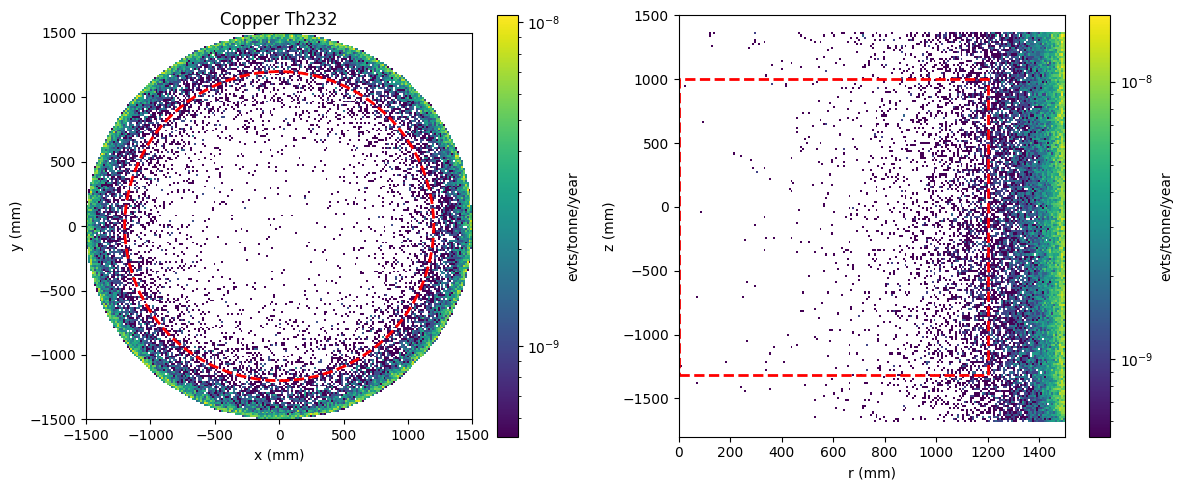

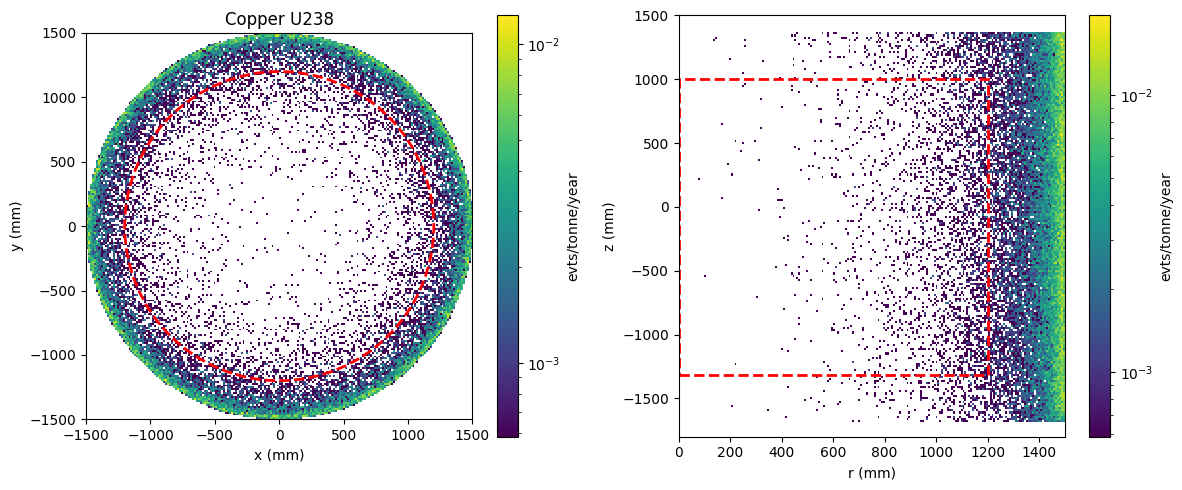

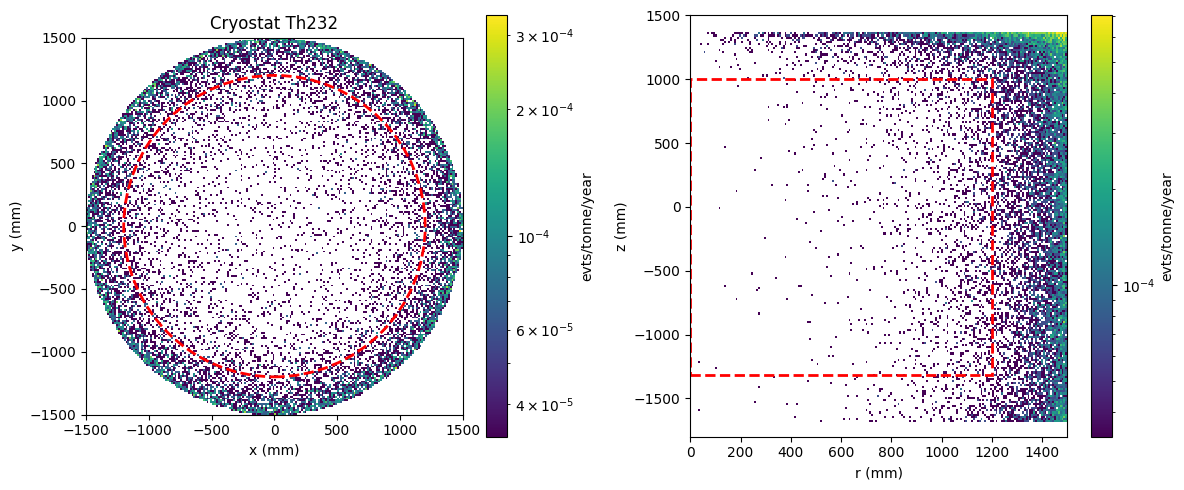

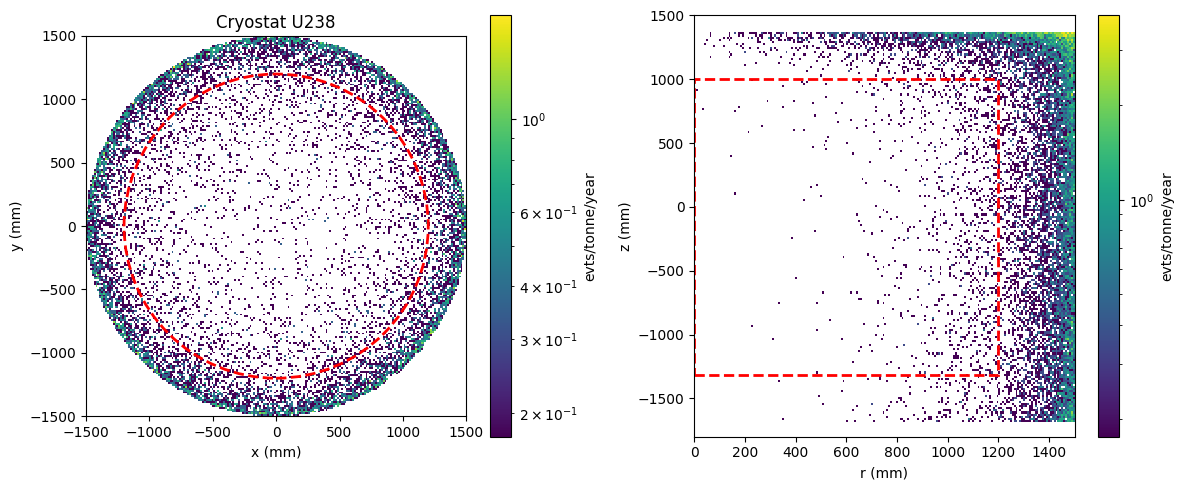

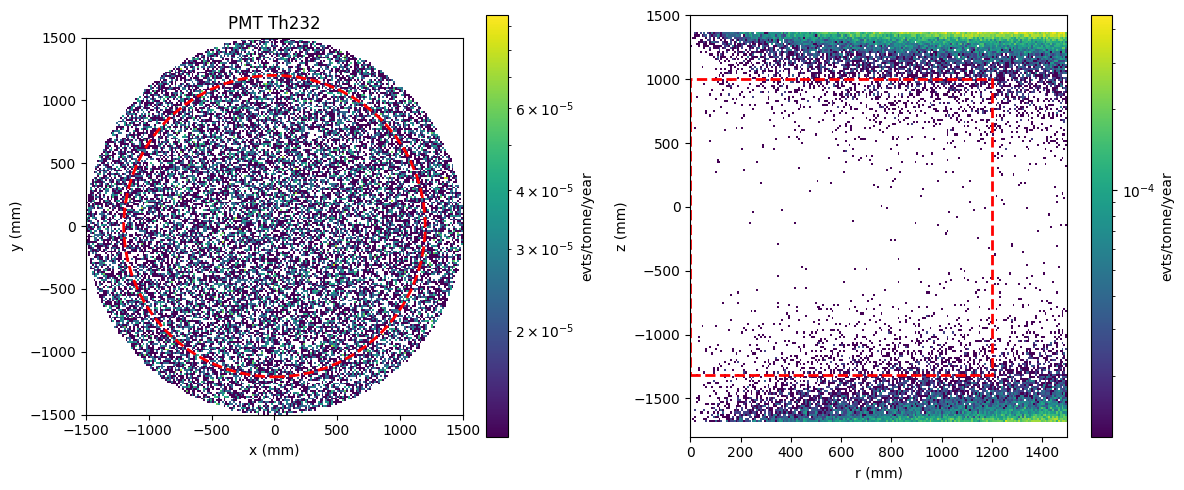

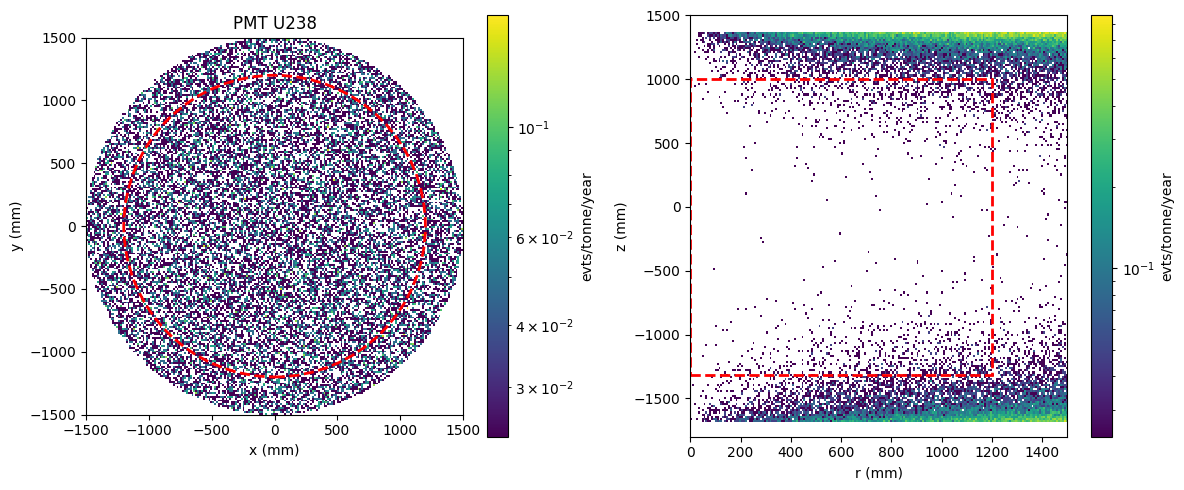

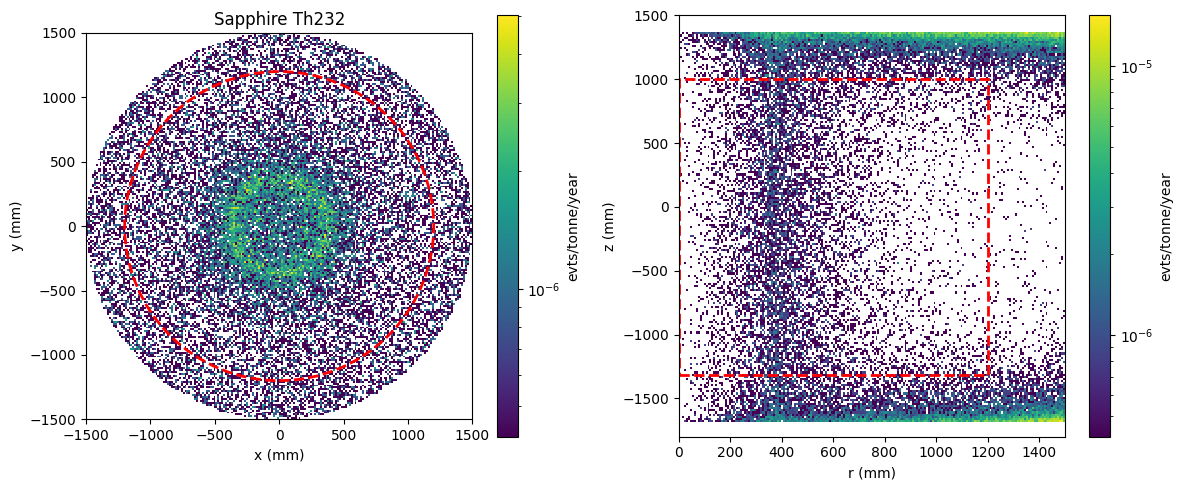

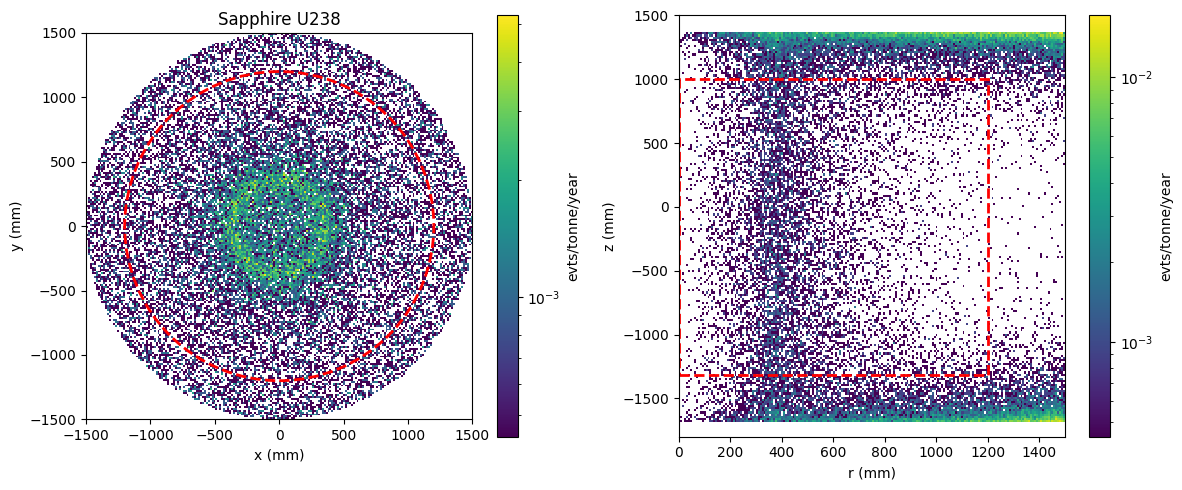

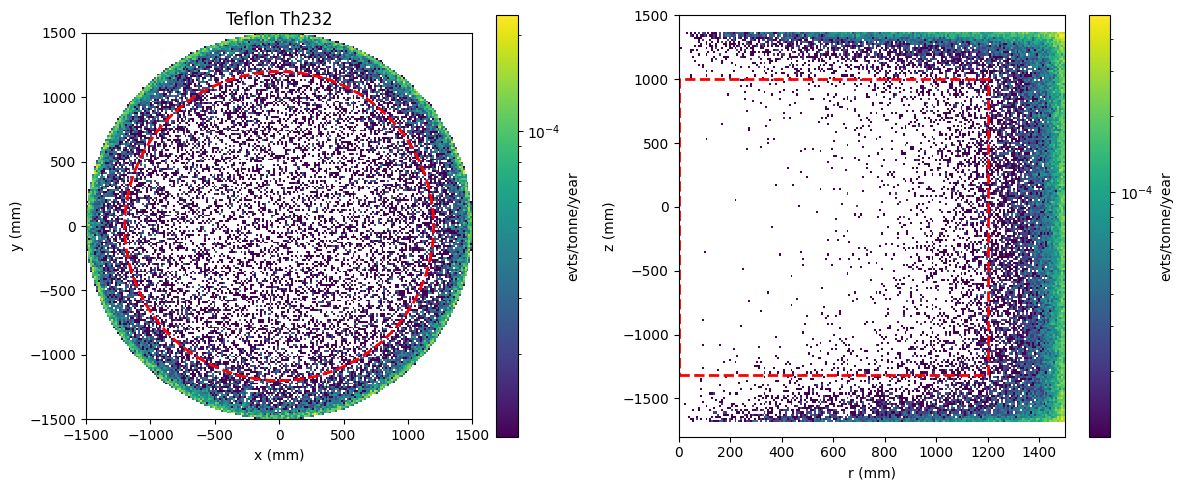

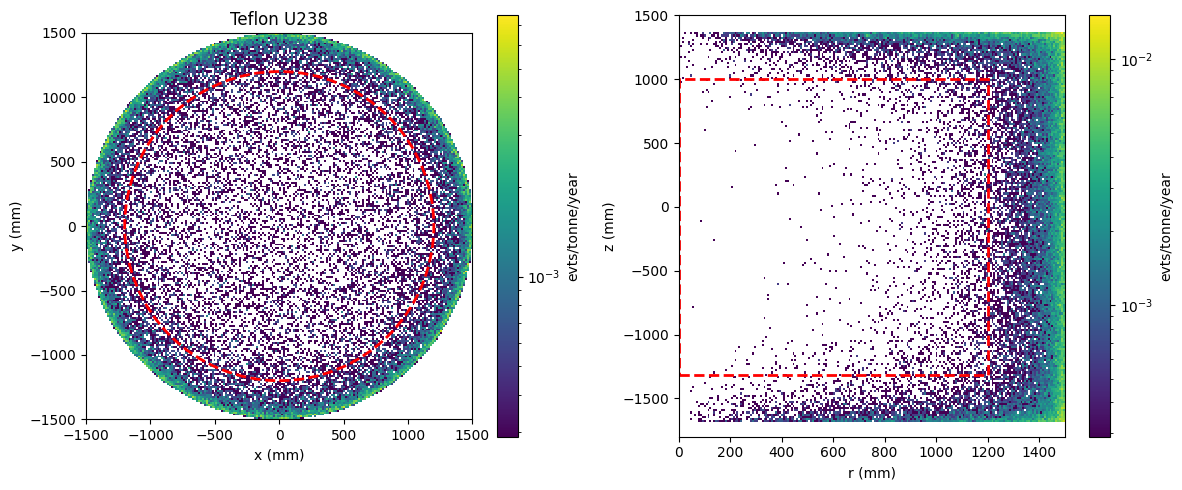

In [111]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

        pcm1 = ax1.pcolormesh(*iso_data["h_xy_ss_energy"].axes.edges.T, iso_data["h_xy_ss_energy"].values().T/iso_data['simulated_exposure_years']/(fv_mass/1e3), norm=matplotlib.colors.LogNorm())
        ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

        ax1.set_title(f"{material} {isotope}")
        ax1.set_xlabel("x (mm)")
        ax1.set_ylabel("y (mm)")
        ax1.set_aspect('equal', adjustable='box')

        pcm2 = ax2.pcolormesh(*iso_data["h_rz_ss_energy"].axes.edges.T, iso_data["h_rz_ss_energy"].values().T/iso_data['simulated_exposure_years']/(fv_mass/1e3), norm=matplotlib.colors.LogNorm())
        ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

        ax2.set_xlabel("r (mm)")
        ax2.set_ylabel("z (mm)")

        plt.colorbar(pcm1, label="evts/tonne/year")
        plt.colorbar(pcm2, label="evts/tonne/year")
        fig.tight_layout()
        plt.show()